# 長短期記憶模型 (Long Short-Term Memory, LSTM)

In [ ]:
import numpy as np

# 指定要讀取的文字檔路徑
filename = "data/shakespeare.txt"

# 讀取整個文字檔內容
data = open(filename, "r").read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print("字元總數 %d, 字符表的長度 %d unique." % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print("字元表中的前 10 個字元：\n", chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print("前 148 個字元：\n", data[:148])

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = {ch: i for i, ch in enumerate(chars)}

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print("字元到索引的映射：\n", char_to_idx)
print("索引到字元的映射：\n", idx_to_char)


def one_hot_idx(idx, vocab_size):
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size))

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1

    # 回傳 one-hot 向量
    return x


# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(char_to_idx["B"], vocab_size)

# 輸出測試結果
print("索引 %d 的 one-hot 向量：\n" % test_idx, one_hot_vector)

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['F', 'K', 'n', 'D', 'm', 'S', 'Y', 'I', 'T', 'R']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

字元到索引的映射：
 {'F': 0, 'K': 1, 'n': 2, 'D': 3, 'm': 4, 'S': 5, 'Y': 6, 'I': 7, 'T': 8, 'R': 9, 'q': 10, 'A': 11, 'E': 12, ';': 13, 'l': 14, 'M': 15, ' ': 16, 'a': 17, 'u': 18, 'v': 19, 'Q': 20, '&': 21, 'B': 22, '.': 23, '3': 24, 'L': 25, 'b': 26, ',': 27, 'j': 28, 'y': 29, 'z': 30, 'G': 31, 'O': 32, '$': 33, 'H': 34, "'": 35, 'g': 36, '?': 37, 'o': 38, 'W': 39, 'x': 40, ':': 41, 't': 42, 'X': 43, 'N': 44, 'r': 45, 'k': 46, 's': 47, 'C': 48, '\n': 49, 'f': 50, 'd': 51, 'V': 52, '-': 53, 'i': 54, 'U': 55, 'c': 56, 'p': 57, 'w': 58, 'J': 59, 'e': 60, 'P': 61, '!': 62, 'Z': 63, 'h': 64}
索引到字元的映射：
 {0: 'F', 1: 'K', 2: 'n', 3: 'D', 4: 'm', 5: 'S', 6: 'Y', 7: 'I', 8: 'T', 9: 'R', 10: 'q', 11: 'A', 12: 'E', 13: ';', 14: 'l', 15: 'M', 16: ' 

## 向前傳播

這段程式碼實作的是 LSTM（Long Short-Term Memory）在處理時間序列資料時的向前傳播流程。  

<img src="image/lstm.webp" alt="lstm" style="width: 70%;"/>

<img src="image/lstm-time-series.webp" alt="lstm in time series" style="width: 70%;"/>

圖片來源： https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/

* Forget Gate (遺忘門，以Sigmoid為啟動函數)
    $$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$

* Input Gate (輸入門)
    $$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$

* Candidate Memory (候選記憶)
    $$\tilde{C}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$

* Cell State (單元狀態更新)
    $$C_t = f_t C_{t-1} + i_t \tilde{C}_t$$

* Output Gate (輸出門)
    $$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$

* Final Hidden State (最終隱藏狀態)
    $$h_t = o_t \odot \tanh(C_t)$$

* Output Layer (輸出層)
    $$y_t = h_t \cdot W_y + b_y$$


### 總結：LSTM 資料流 (Data Flow)

完整的時間步 ($t$) 運算過程：**輸入** $\rightarrow$ **Gate 運算** $\rightarrow$ **記憶更新** $\rightarrow$ **隱藏狀態輸出** $\rightarrow$ **最終輸出**

$$
(x_t, h_{t-1}) \rightarrow (f_t, i_t, o_t, \tilde{C}_t) \rightarrow C_t \rightarrow h_t \rightarrow y_t
$$

流程拆解：
1. 輸入與隱藏狀態：接收當前輸入 $x_t$ 與前一刻的隱藏狀態 $h_{t-1}$。
2. 門控運算（Gate Mechanism）：同時計算遺忘門 ($f_t$)、輸入門 ($i_t$)、輸出門 ($o_t$) 以及候選記憶 ($\tilde{C}_t$)。
3. 記憶更新（Cell State Update）：利用 $f_t$ 遺忘舊記憶，$i_t$ 寫入新記憶，得到新的單元狀態 $C_t$。
4. 隱藏狀態輸出（Hidden State）：透過 $o_t$ 過濾 $C_t$ 的資訊，輸出當前的隱藏狀態 $h_t$。
5. 最終輸出（Output Layer）：藉由隱藏狀態 $h_t$ 計算最終輸出 $y_t$。

In [34]:
def sigmoid(x):
    # sigmoid 啟用函式
    return 1 / (1 + np.exp(-x))


def lstm_forward(params, Xs, state):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 初始 hidden state 與 cell state
    (H, C) = state  # 初始状态

    # 儲存每個時間步的 hidden state 與 cell state
    Hs = {}
    Cs = {}

    # 儲存每個時間步的輸出結果
    Zs = []

    # 額外保留初始狀態，方便後續存取
    Hs[-1] = np.copy(H)
    Cs[-1] = np.copy(C)

    # 儲存每個時間步的 gate 與候選 cell 結果
    Is = []
    Fs = []
    Os = []
    C_tildas = []

    # 逐時間步處理輸入序列
    for t in range(len(Xs)):
        X = Xs[t]

        # 將當前輸入與前一時刻 hidden state 串接，例如：X = [1, 2, 3] , H = [0.5, 0.8]  => XH = [[1, 2, 3, 0.5, 0.8]]
        XH = np.column_stack((X, H))

        # 除錯用區塊，目前不會執行
        if False:
            print("XH.shape", XH.shape)
            print("Wi.shape", Wi.shape)
            break

        # 計算三個 gate 與候選 cell 狀態
        I = sigmoid(np.dot(XH, Wi) + bi)
        F = sigmoid(np.dot(XH, Wf) + bf)
        O = sigmoid(np.dot(XH, Wo) + bo)
        C_tilda = np.tanh(np.dot(XH, Wc) + bc)

        # 更新 cell state
        C = F * C + I * C_tilda

        # 更新 hidden state
        H = O * np.tanh(C)  # O * C.tanh()  #输出状态

        # 經輸出層得到當前時間步輸出
        Y = np.dot(H, Wy) + by  # 输出

        # 紀錄當前時間步結果
        Zs.append(Y)
        Hs[t] = H
        Cs[t] = C

        # 紀錄各 gate 與候選 cell 結果
        Is.append(I)
        Fs.append(F)
        Os.append(O)
        C_tildas.append(C_tilda)

    # 回傳整段序列輸出、各時間步狀態，以及中間 gate 結果
    return Zs, Hs, Cs, (Is, Fs, Os, C_tildas)


def lstm_forward_step(params, X, H, C):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 將當前輸入與前一時刻 hidden state 串接
    XH = np.column_stack((X, H))

    # 計算三個 gate 與候選 cell 狀態
    I = sigmoid(np.dot(XH, Wi) + bi)
    F = sigmoid(np.dot(XH, Wf) + bf)
    O = sigmoid(np.dot(XH, Wo) + bo)
    C_tilda = np.tanh(np.dot(XH, Wc) + bc)

    # 更新 cell state 與 hidden state
    C = F * C + I * C_tilda
    H = O * np.tanh(C)  # O * tanh(C)  #输出状态

    # 經輸出層得到單一步驟輸出
    Y = np.dot(H, Wy) + by  # 输出

    # 回傳輸出、更新後狀態，以及當前步驟的 gate 結果
    return Y, H, C, (I, F, O, C_tilda)

## 反向傳播

這段程式碼實作的是 LSTM 在整段序列上的反向傳播，也就是BPTT（Backpropagation Through Time），將已知每個時間步輸出端傳回來的梯度 \(dZ_t\)，反推出所有參數的梯度，包含：

- LSTM 前向傳播公式
- 鏈式法則（Chain Rule）
- 四個 Gate 的梯度拆解
- 時間反向傳播（BPTT）
- 梯度裁切（Gradient Clipping）

### 啟動函數與導數

#### 1. Sigmoid

$$\sigma(x)=\frac{1}{1+e^{-x}}$$
$$\frac{d}{dx}\sigma(x)=\sigma(x)(1-\sigma(x))$$

#### 2. Tanh

$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$
$$\frac{d}{dx}\tanh(x)=1-\tanh^2(x)$$

### LSTM 前向傳播

#### 1. Gate 計算

$$
\begin{aligned}
i_t &= \sigma(W_i [x_t, h_{t-1}] + b_i) \\
f_t &= \sigma(W_f [x_t, h_{t-1}] + b_f) \\
o_t &= \sigma(W_o [x_t, h_{t-1}] + b_o) \\
\tilde{C}_t &= \tanh(W_c [x_t, h_{t-1}] + b_c)
\end{aligned}
$$

#### 2. Cell State 更新

$$C_t = f_t C_{t-1} + i_t \tilde{C}_t$$

#### 3. Hidden State

$$h_t = o_t \tanh(C_t)$$

### 反向傳播（BPTT）

#### 1. Hidden State 梯度

$$dH_t = dZ_t W_y^T + dH_{t+1}$$

#### 2. Cell State 梯度

$$dC_t = dH_t \cdot o_t \cdot (1 - \tanh^2(C_t)) + dC_{t+1}$$

#### 3. Output Gate

$$
\begin{aligned}
dO_t &= \tanh(C_t) \cdot dH_t \\
dZ_o &= o_t (1 - o_t) \cdot dO_t
\end{aligned}
$$

#### 4. Input Gate

$$
\begin{aligned}
d i_t &= \tilde{C}_t \cdot dC_t \\
dZ_i &= i_t (1 - i_t) \cdot d i_t
\end{aligned}
$$

#### 5. Forget Gate

$$
\begin{aligned}
d f_t &= C_{t-1} \cdot dC_t \\
dZ_f &= f_t (1 - f_t) \cdot d f_t
\end{aligned}
$$

#### 6. Candidate Cell

$$
\begin{aligned}
d\tilde{C}_t &= i_t \cdot dC_t \\
dZ_c &= (1 - \tilde{C}_t^2) \cdot d\tilde{C}_t
\end{aligned}
$$

#### 7. Cell State 傳遞

$$dC_{t-1} = f_t \cdot dC_t$$

### 參數梯度

#### 1. 權重（以 output gate 為例）

$$dW_o = [x_t, h_{t-1}]^T \cdot dZ_o$$

#### 2. 偏置

$$db_o = \sum dZ_o$$

### 梯度裁切（Gradient Clipping）

#### 1. L2 Norm

$$\|g\|_2 = \sqrt{\sum_i g_i^2}$$

#### 2. 梯度縮放

$$g \leftarrow g \cdot \frac{\alpha}{\|g\|}, \quad \text{if } \|g\| > \alpha$$

In [35]:
import math


def dsigmoid(x):
    # sigmoid 的導數
    return sigmoid(x) * (1 - sigmoid(x))


def dtanh(x):
    # tanh 的導數
    return 1 - np.tanh(x) * np.tanh(x)


def grad_clipping(grads, alpha):
    # 計算所有梯度的整體 L2 norm
    norm = math.sqrt(sum((grad**2).sum() for grad in grads))

    # 若超過門檻，則按比例縮放所有梯度
    if norm > alpha:
        ratio = alpha / norm
        for i in range(len(grads)):
            grads[i] *= ratio


def lstm_backward(params, Xs, Hs, Cs, dZs, cache, clip_value=5.0):  # Ys,loss_function):
    # 取出 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 取出前向傳播保留的 gate 與候選 cell 結果
    Is, Fs, Os, C_tildas = cache

    # 初始化各參數梯度
    dWi, dWf, dWo, dWc, dWy = (
        np.zeros_like(Wi),
        np.zeros_like(Wf),
        np.zeros_like(Wo),
        np.zeros_like(Wc),
        np.zeros_like(Wy),
    )
    dbi, dbf, dbo, dbc, dby = (
        np.zeros_like(bi),
        np.zeros_like(bf),
        np.zeros_like(bo),
        np.zeros_like(bc),
        np.zeros_like(by),
    )

    # 初始化從下一時間步回傳的 hidden state 與 cell state 梯度
    dH_next = np.zeros_like(Hs[0])
    dC_next = np.zeros_like(Cs[0])

    # 取得輸入特徵維度，用於後續拆分 dXH_
    input_dim = Xs[0].shape[1]

    # 簡化變數名稱
    h = Hs
    x = Xs

    # 序列長度
    T = len(Xs)

    # 依時間反向走訪
    for t in reversed(range(T)):
        # 取出當前時間步前向傳播保存的中間結果
        I = Is[t]
        F = Fs[t]
        O = Os[t]
        C_tilda = C_tildas[t]
        H = Hs[t]
        X = Xs[t]
        C = Cs[t]
        H_pre = Hs[t - 1]
        C_prev = Cs[t - 1]

        # 將當前輸入與前一時刻 hidden state 串接
        XH_pre = np.column_stack((X, H_pre))
        XH_ = XH_pre

        # 當前時間步來自輸出端的梯度
        dZ = dZs[t]

        # 輸出層參數梯度
        dWy += np.dot(H.T, dZ)
        dby += np.sum(dZ, axis=0, keepdims=True)

        # hidden state 的總梯度
        # 包含目前輸出層傳回的梯度，以及下一時間步回傳的梯度
        dH = np.dot(dZ, Wy.T) + dH_next

        # cell state 的總梯度
        dC = dH * O * dtanh(C) + dC_next  # H_t= O_t*tanh(C_t)

        # output gate 梯度
        dO = np.tanh(C) * dH
        dOZ = O * (1 - O) * dO  # O = sigma(Z_o)
        dWo += np.dot(XH_.T, dOZ)  # Z_o = (X,H_)W_o+b_o
        dbo += np.sum(dOZ, axis=0, keepdims=True)

        # input gate 梯度
        di = C_tilda * dC
        diZ = I * (1 - I) * di
        dWi += np.dot(XH_.T, diZ)
        dbi += np.sum(diZ, axis=0, keepdims=True)

        # forget gate 梯度
        df = C_prev * dC
        dfZ = F * (1 - F) * df
        dWf += np.dot(XH_.T, dfZ)
        dbf += np.sum(dfZ, axis=0, keepdims=True)

        # 候選 cell 狀態梯度
        dC_tilda = I * dC  # C = F * C + I * C_tilda
        dC_tilda_Z = (1 - np.square(C_tilda)) * dC_tilda  # C_tilda = tanh(C_tilda_Z)
        dWc += np.dot(XH_.T, dC_tilda_Z)  # C_tilda_Z = (X,H_)W_c+b_c
        dbc += np.sum(dC_tilda_Z, axis=0, keepdims=True)

        # 將各 gate 傳回輸入與前一 hidden state 的梯度合併
        dXH_ = (
            np.dot(dfZ, Wf.T)
            + np.dot(diZ, Wi.T)
            + np.dot(dC_tilda_Z, Wc.T)
            + np.dot(dOZ, Wo.T)
        )

        # 拆出對輸入與前一 hidden state 的梯度
        dX_prev = dXH_[:, :input_dim]
        dH_prev = dXH_[:, input_dim:]

        # 傳回前一 cell state 的梯度
        dC_prev = F * dC

        # 更新傳給前一時間步的梯度
        dC_next = dC_prev
        dH_next = dH_prev

    # 整理所有參數梯度
    grads = [dWi, dbi, dWf, dbf, dWo, dbo, dWc, dbc, dWy, dby]

    # 做梯度裁切，避免梯度爆炸
    grad_clipping(grads, clip_value)

    # for dparam in [dWi, dbi,dWf, dbf, dWo,dbo,dWc, dbc,dWy,dby]:
    #    np.clip(dparam, -5, 5, out=dparam) # clip to mitigate exploding gradients

    return grads

## 初始化

In [36]:
import numpy as np


def lstm_params_init(input_dim, hidden_dim, output_dim, scale=0.01):
    # 建立常態分布隨機初始化函式，用於產生權重矩陣
    normal = lambda m, n: np.random.randn(m, n) * scale

    # 建立單一 gate 的權重與偏置
    # 權重輸入維度為 input_dim + hidden_dim，輸出維度為 hidden_dim
    two = lambda: (
        normal(input_dim + hidden_dim, hidden_dim),
        np.zeros((1, hidden_dim)),
    )

    # 各 gate 參數初始化
    Wi, bi = two()  # Input gate parameters
    Wf, bf = two()  # Forget gate parameters
    Wo, bo = two()  # Output gate parameters
    Wc, bc = two()  # Candidate cell parameters

    # 輸出層參數初始化
    Wy = normal(hidden_dim, output_dim)
    by = np.zeros((1, output_dim))

    # 依固定順序整理所有參數，供前向傳播函式使用
    params = [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by]
    return params


def lstm_state_init(batch_size, hidden_size):
    # 初始化隱藏狀態 H 與記憶狀態 C
    return (np.zeros((batch_size, hidden_size)), np.zeros((batch_size, hidden_size)))

## 測試前向與反向傳播是否正確

In [37]:
import rnn as rnn  # 匯入自定義 RNN 模組，並使用 fr 作為別名
import util as util  # 匯入工具模組，並使用 util 作為別名

# 設定序列長度、輸入維度、隱藏層維度、輸出維度與 batch size
T = 3
input_dim, hidden_dim, output_dim = 4, 3, 4
batch_size = 2

# 建立隨機輸入序列，形狀為 (T, batch_size, input_dim)
Xs = np.random.randn(T, batch_size, input_dim)

# 建立隨機標籤，形狀為 (T, batch_size)
Ys = np.random.randint(output_dim, size=(T, batch_size))

# 印出測試資料
print("Xs", Xs)
print("Ys", Ys)

# gradient check 前的參數與狀態初始化
params = lstm_params_init(input_dim, hidden_dim, output_dim)
HC = lstm_state_init(batch_size, hidden_dim)

# 前向傳播，取得輸出、各時間步狀態與快取資料
Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

# 透過 loss function 計算 loss 與輸出端梯度
loss_function = rnn.rnn_loss_grad
loss, dZs = loss_function(Zs, Ys)

# 反向傳播，取得解析梯度
grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)


def rnn_loss():
    # 重新初始化狀態，避免前次執行結果影響 loss 計算
    HC = lstm_state_init(batch_size, hidden_dim)

    # 重新執行前向傳播
    Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

    # 重新計算 loss
    loss_function = rnn.rnn_loss_grad
    loss, dZs = loss_function(Zs, Ys)
    return loss


# 使用數值微分計算各參數的梯度，作為 gradient check 依據
numerical_grads = util.numerical_gradient(
    rnn_loss, params, 1e-6
)  # rnn_numerical_gradient(rnn_loss,params,1e-10)

# 定義最大絕對誤差
# diff_error = lambda x, y: np.max( np.abs(x - y)/(np.maximum(1e-8, np.abs(x) + np.abs(y))))
diff_error = lambda x, y: np.max(np.abs(x - y))


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


# 印出 loss
print("loss", loss)

# 印出各組參數梯度的誤差
print("[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] ")
for i in range(len(grads)):
    print(diff_error(grads[i], numerical_grads[i]))

# 額外印出第一組權重梯度與其數值梯度，方便比對
print("grads", grads[0])
print("numerical_grads", numerical_grads[0])

Xs [[[-1.11359149  0.21221449  0.49622753  1.33896751]
  [ 0.78515297  0.51046973  1.32227892 -0.87919342]]

 [[-0.29016728  1.5193085  -1.94210813  0.13549051]
  [-0.59521837  0.89522643 -0.66606595 -0.6803311 ]]

 [[ 0.30440733 -1.76225777  0.43432611  0.62825498]
  [ 0.01284397 -0.11292547  0.5192543   0.46385918]]]
Ys [[1 2]
 [0 0]
 [0 3]]
loss 4.158862242205734
[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] 
4.124871405474461e-10
2.444642295958518e-10
3.860383761889244e-10
5.138394316024078e-10
4.493003225278415e-10
2.5388222040222683e-10
5.28308427821117e-10
1.347702906304843e-10
3.8032361765125144e-10
1.0769463099080667e-10
grads [[-1.50642038e-05  7.31413952e-06 -1.06607202e-06]
 [ 2.07035576e-05 -3.56379701e-06 -6.91110958e-06]
 [-1.42320605e-05  1.39086486e-05 -2.96983013e-07]
 [ 9.26017981e-06 -1.54871199e-05  4.26247080e-06]
 [-5.92532999e-09 -4.70900024e-08 -6.34526936e-09]
 [ 4.17064001e-08  3.38509677e-08 -1.31941096e-08]
 [ 2.57149811e-08  3.95567263e-08 -1.20541556e-08]]
numerica

## 訓練函式

In [38]:
def lstm_train_epoch(
    params, data_iter, optimizer, iterations, loss_function, print_n=100
):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 紀錄每次迭代的 loss
    losses = []

    # 迭代計數器
    iter = 0

    batch_size = None

    # 由輸出層權重推得 hidden state 維度
    hidden_size = Wy.shape[0]

    # 先將狀態設為 None，避免未初始化就使用
    HC = None

    # 逐批次讀取資料
    for Xs, Ys, start in data_iter:
        # 第一次進來時，從輸入資料推得 batch size
        if batch_size is None:
            batch_size = Xs[0].shape[0]

        # 若為新序列起點，或目前尚未有狀態，則初始化 hidden state 與 cell state
        if start or HC is None:
            HC = lstm_state_init(batch_size, hidden_size)

        # 前向傳播
        Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

        # 計算 loss 與輸出端梯度
        loss, dZs = loss_function(Zs, Ys)

        # 反向傳播，取得各參數梯度
        grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)

        # 使用 optimizer 更新參數
        optimizer.step(grads)

        # 將最後一個時間步的狀態保存下來，供下一個 batch 延續使用
        HC = (Hs[len(Xs) - 1], Cs[len(Xs) - 1])

        # 紀錄當前 loss
        losses.append(loss)

        # 依指定間隔印出訓練資訊
        if iter % print_n == 0:
            print("iter %d, loss: %f" % (iter, loss))

        iter += 1

        # 超過指定迭代次數後停止
        if iter > iterations:
            break

    # 回傳整個 epoch 的 loss 與最後狀態
    return losses, HC

In [39]:
def character_seq_data_iter_consecutive(
    data, batch_size, seq_len, vocab_size, start_range=10
):
    # 隨機決定本輪資料切分的起始偏移，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    # -1 是因為標籤 Y 需要對應到下一個字元
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個 block 最多可切出幾個完整的 seq_len 批次
    num_batches = block_len // seq_len

    # 建立每個 block 在原始資料中的起始偏移量
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總時間步數，避免超出完整批次範圍
    i_end = num_batches * seq_len

    # 依 seq_len 為單位，逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        # 本批次在原始資料中的起始位置
        s = start + i

        # X: 輸入序列，使用 one-hot 表示字元
        # shape = (seq_len, batch_size, vocab_size)
        X = np.empty((seq_len, batch_size, vocab_size), dtype=np.int32)

        # Y: 目標序列，儲存下一個字元的索引
        # shape = (seq_len, batch_size, 1)
        Y = np.empty((seq_len, batch_size, 1), dtype=np.int32)

        # 逐一處理 batch 中的每個樣本
        for b in range(batch_size):
            # 取得第 b 個 block 在本批次中的起始位置
            s_b = s + bs[b]

            # 依時間步填入輸入 X 與標籤 Y
            for t in range(seq_len):
                # 目前字元轉為索引後，再轉成 one-hot 向量作為輸入
                X[t, b, :] = one_hot_idx(char_to_idx[data[s_b]], vocab_size)

                # 下一個字元的索引作為預測目標
                Y[t, b, :] = char_to_idx[data[s_b + 1]]

                # 往下一個時間步前進
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為起始批次
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

## 設定並執行 LSTM 模型

iter 0, loss: 104.357583
iter 10, loss: 96.081667
iter 20, loss: 87.497711
iter 30, loss: 82.515483
iter 40, loss: 85.495618
iter 50, loss: 77.853856
iter 60, loss: 76.722072
iter 70, loss: 76.144087
iter 80, loss: 86.085861
iter 90, loss: 84.065547
iter 100, loss: 93.585785
iter 110, loss: 80.192579
iter 120, loss: 77.142510
iter 130, loss: 76.130151
iter 140, loss: 76.763257
iter 150, loss: 81.844461
iter 160, loss: 82.208661
iter 170, loss: 77.516731
iter 180, loss: 88.056179
iter 190, loss: 89.706062
iter 200, loss: 72.679671
iter 210, loss: 78.691539
iter 220, loss: 88.562473
iter 230, loss: 69.568327
iter 240, loss: 75.365037
iter 250, loss: 75.364606
iter 260, loss: 71.494093
iter 270, loss: 71.806044
iter 280, loss: 71.204793
iter 290, loss: 73.731809
iter 300, loss: 69.160623
iter 310, loss: 62.672469
iter 320, loss: 64.424831
iter 330, loss: 67.110199
iter 340, loss: 61.440446
iter 350, loss: 73.284068
iter 360, loss: 68.838826
iter 370, loss: 56.586363
iter 380, loss: 72.035

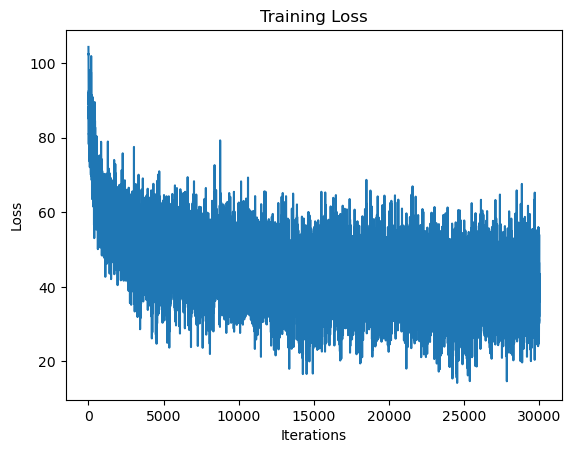

In [40]:
import matplotlib.pyplot as plt

# 設定模型輸入維度、隱藏層維度與輸出維度
# 這裡輸入與輸出都以 vocab_size 為基準，適合字元級模型
input_dim, hidden_dim, output_dim = vocab_size, 100, vocab_size

# 設定 batch size
batch_size = 2

# 初始化 LSTM 參數
params = lstm_params_init(input_dim, hidden_dim, output_dim)

# 初始化 LSTM 狀態
H = lstm_state_init(batch_size, hidden_dim)

# 每段訓練序列的長度
seq_length = 25

# 設定 loss function，回傳 loss 與對輸出層的梯度
loss_function = lambda F, Y: rnn.rnn_loss_grad(F, Y)  # ,util.loss_grad_least)

# 設定訓練回合數
epoches = 3

# 設定學習率
learning_rate = 1e-2

# 每個 epoch 允許的最大迭代次數
iterations = 10000

# 用來累積整體訓練過程中的 loss
losses = []

# 建立 AdaGrad optimizer
optimizer = rnn.AdaGrad(params, learning_rate)

# 設定 momentum
momentum = 0.9

# 改用 SGD optimizer，並帶入 momentum
# 此行會覆蓋前面建立的 AdaGrad optimizer
optimizer = rnn.SGD(params, learning_rate, momentum)

# 逐個 epoch 執行訓練
for epoch in range(epoches):
    # 建立連續字元序列資料迭代器
    data_it = character_seq_data_iter_consecutive(
        data, batch_size, seq_length, vocab_size, 100
    )

    # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)

    # 執行單一 epoch 的 LSTM 訓練
    epoch_losses, H = lstm_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=10
    )

    # 累加本 epoch 的所有 loss
    losses.extend(epoch_losses)

    # epoch_losses = np.array(epoch_losses).mean()
    # losses.append(epoch_losses)

# ===== 繪製訓練 loss 曲線 =====
plt.plot(losses[:])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## 文字生成

In [41]:
def predict_lstm(params, prefix, n):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 由參數形狀推回詞彙大小與 hidden state 維度
    vocab_size, hidden_dim = Wi.shape[0] - Wy.shape[0], Wy.shape[0]

    # 初始化單筆預測時使用的 hidden state 與 cell state
    h, c = lstm_state_init(1, hidden_dim)

    # 先放入 prefix 的第一個字元索引，作為生成起點
    output = [char_to_idx[prefix[0]]]

    # 總共跑 prefix 長度加上欲生成長度，再扣掉已放入的第一個字元
    for t in range(len(prefix) + n - 1):
        # 將上一時間步的輸出字元轉成 one-hot，作為目前時間步輸入
        x = one_hot_idx(output[-1], vocab_size)

        # 執行單一步驟前向傳播，更新輸出與狀態
        z, h, c, _ = lstm_forward_step(params, x, h, c)

        # 在 prefix 範圍內時，直接使用 prefix 的下一個字元
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            # 將輸出轉成機率分布
            p = np.exp(z) / np.sum(np.exp(z))

            # idx = int(p.argmax(axis=1))

            # 依機率分布隨機取樣下一個字元
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)

    # 將索引序列轉回字元字串
    return "".join([idx_to_char[i] for i in output])

In [42]:
str = predict_lstm(params, "he", 500)
print(str)

her,
And sintardons shall lived you's him, lever notearn:
Ully him whom the sick
bownred on disportany dark, come hirded,
Pack boy, that fill say deed our canidents some to,
With in the breast of the words,
Three incetiminglow.

First Lord:
Moreed, my lifed whom on thes! Came,
To maint with a&fair citrae man.

YORK:
My good
From as your Lady cloughtle pptclef his low hiseel us
And comserved you than your beaning;
Muckness this duch can but there is
Your your eye
To shall -sby, houl, fair cround no


# GRU（閘門循環單元，Gated Recurrent Unit）

GRU 是一種循環神經網路（RNN）的變體，設計目的是在處理序列資料（如時間序列、語言）時，改善傳統 RNN 的「梯度消失（vanishing gradient）」問題，同時維持較低的模型複雜度。

## 核心概念

GRU 的關鍵在於「門控機制（gating mechanism）」，用來控制資訊在時間序列中的流動與保留。相比 LSTM，GRU 結構更簡化，僅包含兩個 gate：

1. **Update Gate（更新門，U）**
2. **Reset Gate（重設門，R）**

沒有獨立的 cell state（像 LSTM），而是直接用 hidden state 表示記憶。

GRU 相較於 LSTM 結構較簡單、參數較少，因此通常更省計算資源；可以視為對 LSTM 的簡化設計，同時仍保留 gate 機制來緩解傳統 RNN 的梯度消失問題，但在極長期依賴任務上可能略遜於 LSTM。

## 數學結構

在時間步 $t$，給定輸入 $x_t$ 與前一隱藏狀態 $h_{t-1}$：

1. Update Gate

控制「保留多少舊資訊」

$$
U_t = \sigma(x_t W_u + h_{t-1} W_{hu} + b_u)
$$

2. Reset Gate

控制「忽略多少舊資訊」

$$
R_t = \sigma(x_t W_r + h_{t-1} W_{hr} + b_r)
$$

3. Candidate Hidden State

利用 reset gate 決定如何使用舊狀態

$$
\tilde{h}_t = \tanh(x_t W_h + (R_t \odot h_{t-1}) W_{hh} + b_h)
$$

4. 最終 Hidden State 更新

在舊資訊與新資訊之間做加權

$$
h_t = U_t \odot h_{t-1} + (1 - U_t) \odot \tilde{h}_t
$$

## 直觀理解

可以用「記憶控制」來理解：

- **Update Gate（U）**
  - 接近 1 → 保留舊記憶（long-term memory）
  - 接近 0 → 使用新資訊

- **Reset Gate（R）**
  - 接近 0 → 忘記過去（適合新上下文）
  - 接近 1 → 保留過去資訊

## 與 LSTM 的差異

| 項目 | GRU | LSTM |
|------|-----|------|
| Gate 數量 | 2（U, R） | 3（input, forget, output） |
| Cell state | 無 | 有 |
| 計算量 | 較少 | 較多 |
| 表現 | 通常接近 LSTM | 稍強但較重 |

實務上：

- 資料量不大或需要快速訓練 → 常用 GRU
- 長期依賴很強 → LSTM 有時更穩定

## 優缺點總結

### 優點
- 結構簡單，參數較少  
- 訓緓速度快  
- 能處理中長期依賴  

### 缺點
- 表達能力略低於 LSTM（部分任務）  
- gate 行為仍較難直觀解釋  

## 程式說明

這段程式碼實作了一個以 NumPy 為基礎的 GRU（Gated Recurrent Unit）模型核心流程，包含：

- `sigmoid(x)`：提供 GRU gate 會用到的 sigmoid 啟用函式
- `gru_init_params(...)`：初始化 GRU 的權重與偏置參數
- `gru_state_init(...)`：初始化隱藏狀態
- `gru_forward(...)`：執行 GRU 前向傳播，逐時間步計算更新 gate、重設 gate、候選隱藏狀態、最終隱藏狀態與輸出
- `gru_backward(...)`：根據前向傳播暫存的中間結果與輸出梯度，反向計算各參數的梯度

執行流程

1. 先透過 `gru_init_params(...)` 建立 GRU 所需參數，包括：
   - update gate：`Wxu`, `Whu`, `bu`
   - reset gate：`Wxr`, `Whr`, `br`
   - candidate hidden state：`Wxh`, `Whh`, `bh`
   - output layer：`Wy`, `by`

2. 透過 `gru_state_init(...)` 依照 batch size 與 hidden size 建立初始隱藏狀態 `H_0`

3. 在 `gru_forward(...)` 中，對輸入序列 `Xs` 逐步執行：
   - 計算更新 gate `U`
   - 計算重設 gate `R`
   - 計算候選隱藏狀態 `H_tilda`
   - 混合前一個隱藏狀態與候選狀態，得到新的隱藏狀態 `H`
   - 再由 `H` 經過輸出層得到 `Y`

4. 在 `gru_backward(...)` 中，依照時間反向展開：
   - 先從輸出層梯度 `dZs` 回傳到隱藏狀態
   - 再依序拆解到 `H_tilda`、`U`、`R`
   - 最後累加各時間步對參數的梯度

重要補充
- `Hs` 使用 dictionary 儲存每個時間步的隱藏狀態，並用 `Hs[-1]` 保存初始隱藏狀態，方便反向傳播時直接取前一時刻狀態
- `cache` 內保存 `(Rs, Us, H_tildas)`，供 backward 使用
- `gru_backward(...)` 也有計算 `dX`，但目前沒有作為回傳值輸出
- 這段程式碼聚焦在 GRU 單層的前向與反向傳播核心計算，未包含 loss function、參數更新與訓練迴圈

In [43]:
import numpy as np


def sigmoid(x):
    # sigmoid 啟用函式，供 update gate 與 reset gate 使用
    return 1 / (1 + np.exp(-x))


def gru_init_params(input_dim, hidden_dim, output_dim, scale=0.01):
    # 產生常態分佈初始化權重，並依 scale 縮放
    normal = lambda m, n: np.random.randn(m, n) * scale

    # 產生一組 gate / hidden state 對應的輸入權重、隱藏權重與偏置
    three = lambda: (
        normal(input_dim, hidden_dim),
        normal(hidden_dim, hidden_dim),
        np.zeros((1, hidden_dim)),
    )

    Wxu, Whu, bu = three()  # Update gate 參數
    Wxr, Whr, br = three()  # Reset gate 參數
    Wxh, Whh, bh = three()  # Candidate hidden state 參數

    # 輸出層參數
    Wy = normal(hidden_dim, output_dim)
    by = np.zeros((1, output_dim))

    # 依固定順序回傳所有參數，供 forward / backward 共用
    params = [Wxu, Whu, bu, Wxr, Whr, br, Wxh, Whh, bh, Wy, by]
    return params


def gru_state_init(batch_size, hidden_size):
    # 初始化隱藏狀態，起始值為 0
    return np.zeros((batch_size, hidden_size))


def gru_forward(params, Xs, H_0):
    # 取出所有 GRU 與輸出層參數
    Wxu, Whu, bu, Wxr, Whr, br, Wxh, Whh, bh, Wy, by = params

    # 目前時間步的隱藏狀態，初始值為 H_0
    H = H_0

    # 儲存各時間步的隱藏狀態
    Hs = {}

    # 儲存各時間步的輸出
    Ys = []

    # 額外保留初始隱藏狀態，方便 backward 直接取前一時間步
    Hs[-1] = np.copy(H)

    # 儲存 backward 需要的中間結果
    Rs = []
    Us = []
    H_tildas = []

    # 逐時間步處理輸入序列
    for t in range(len(Xs)):
        X = Xs[t]

        # 計算 update gate
        U = sigmoid(np.dot(X, Wxu) + np.dot(H, Whu) + bu)

        # 計算 reset gate
        R = sigmoid(np.dot(X, Wxr) + np.dot(H, Whr) + br)

        # 計算候選隱藏狀態
        H_tilda = np.tanh(np.dot(X, Wxh) + np.dot(R * H, Whh) + bh)

        # 依照 update gate 混合前一隱藏狀態與候選狀態
        H = U * H + (1 - U) * H_tilda

        # 由隱藏狀態映射到輸出
        Y = np.dot(H, Wy) + by

        # 保存各時間步結果
        Hs[t] = H
        Ys.append(Y)
        Rs.append(R)
        Us.append(U)
        H_tildas.append(H_tilda)

    # 回傳輸出、隱藏狀態，以及 backward 所需 cache
    return Ys, Hs, (Rs, Us, H_tildas)

In [44]:
def gru_backward(params, Xs, Hs, dZs, cache):  # Ys,loss_function):
    # 取出所有 GRU 與輸出層參數
    Wxu, Whu, bu, Wxr, Whr, br, Wxh, Whh, bh, Wy, by = params
    Rs, Us, H_tildas = cache

    # 初始化各參數梯度
    dWxu, dWhu, dWxr, dWhr, dWxh, dWhh, dWy = (
        np.zeros_like(Wxu),
        np.zeros_like(Whu),
        np.zeros_like(Wxr),
        np.zeros_like(Whr),
        np.zeros_like(Wxh),
        np.zeros_like(Whh),
        np.zeros_like(Wy),
    )
    dbu, dbr, dbh, dby = (
        np.zeros_like(bu),
        np.zeros_like(br),
        np.zeros_like(bh),
        np.zeros_like(by),
    )

    # 從最後一個時間步往前傳遞的隱藏狀態梯度
    dH_next = np.zeros_like(Hs[0])

    input_dim = Xs[0].shape[1]

    T = len(Xs)

    # 依時間反向展開
    for t in reversed(range(T)):
        R = Rs[t]
        U = Us[t]
        H = Hs[t]
        X = Xs[t]
        H_tilda = H_tildas[t]
        H_pre = Hs[t - 1]

        dZ = dZs[t]

        # 輸出層參數梯度
        dWy += np.dot(H.T, dZ)
        dby += np.sum(dZ, axis=0, keepdims=True)

        # 隱藏狀態梯度 = 目前輸出反傳 + 未來時間步反傳回來的梯度
        dH = np.dot(dZ, Wy.T) + dH_next

        # H = U * H_pre + (1 - U) * H_tilda
        # 拆解對 H_tilda、H_pre、U 的梯度
        dH_tilda = dH * (1 - U)
        dH_pre = dH * U
        dU = H_pre * dH - H_tilda * dH

        # H_tilda = tanh(X Wxh + (R * H_pre) Whh + bh)
        # 先對 tanh 輸入反傳，再累加對應參數梯度
        dH_tildaZ = (1 - np.square(H_tilda)) * dH_tilda
        dWxh += np.dot(X.T, dH_tildaZ)
        dWhh += np.dot((R * H_pre).T, dH_tildaZ)
        dbh += np.sum(dH_tildaZ, axis=0, keepdims=True)

        # 拆出 reset gate 與前一隱藏狀態的梯度
        dR = np.dot(dH_tildaZ, Whh.T) * H_pre
        dH_pre += np.dot(dH_tildaZ, Whh.T) * R

        # U = sigmoid(UZ), R = sigmoid(RZ)
        # 將 gate 輸出梯度轉回 gate 線性輸入梯度
        dUZ = U * (1 - U) * dU
        dRZ = R * (1 - R) * dR

        # 將 gate 對前一隱藏狀態的影響累加回 dH_pre
        dH_pre += np.dot(dUZ, Whu.T)
        dH_pre += np.dot(dRZ, Whr.T)

        # reset gate 參數梯度
        dWxr += np.dot(X.T, dRZ)
        dWhr += np.dot(H_pre.T, dRZ)
        dbr += np.sum(dRZ, axis=0, keepdims=True)

        # update gate 參數梯度
        dWxu += np.dot(X.T, dUZ)
        dWhu += np.dot(H_pre.T, dUZ)
        dbu += np.sum(dUZ, axis=0, keepdims=True)

        # 計算對輸入 X 的梯度
        if True:
            dX_RZ = np.dot(dRZ, Wxr.T)
            dX_UZ = np.dot(dUZ, Wxu.T)
            dX_H_tildaZ = np.dot(dH_tildaZ, Wxh.T)
            dX = dX_RZ + dX_UZ + dX_H_tildaZ

        # 傳給前一個時間步的隱藏狀態梯度
        dH_next = dH_pre

    # 依與 params 相同的順序回傳所有參數梯度
    return [dWxu, dWhu, dbu, dWxr, dWhr, dbr, dWxh, dWhh, dbh, dWy, dby]

In [45]:
def softmax(Z):
    # 對輸入的 Z 做 softmax，先減掉最大值避免數值爆掉
    A = np.exp(Z - np.max(Z, axis=-1, keepdims=True))
    # 將指數結果做正規化，讓每一列加起來等於 1
    return A / np.sum(A, axis=-1, keepdims=True)


def softmax_cross_entropy(Z, y, onehot=False):
    # 樣本的總數（有幾筆資料）
    m = len(Z)

    # 先把模型輸出 Z 丟進 softmax，算出每一類的機率
    F = softmax(Z)

    if onehot:
        # 如果 y 是 one-hot 編碼
        # 直接用 cross entropy 的公式算 loss
        loss = -np.sum(y * np.log(F)) / m
    else:
        # 如果 y 是類別的 index（例如 0、1、2）
        # 把 y 攤平成一維（但這行實際上不會影響後面）
        y.flatten()

        # 取出每筆資料「正確類別」對應的機率，再取 log
        log_Fy = -np.log(F[range(m), y])

        # 把所有樣本的 loss 加起來，再取平均
        loss = np.sum(log_Fy) / m

    return loss


def cross_entropy_grad_loss(Z, y, softmax_out=False, onehot=False):
    """
    優化後的函式：共用 Softmax 運算結果，同時回傳 Loss 與 Gradient。
    """
    # 1. 決定機率分布 F (Softmax 的結果)
    if softmax_out:
        # 如果已經是 Softmax 輸出，直接共用
        F = Z
    else:
        # 如果是 Logits，算一次 Softmax 就好，後面大家都用這份 F
        F = softmax(Z)

    # 2. 計算 Loss
    # 注意：這裡我們傳入已經算好的 F，並告訴後面的函式 softmax_out=True
    # (假設你原有的 softmax_cross_entropy 有支援這個判斷，或是我們直接在這裡算)
    m = len(y)
    if onehot:
        loss = -np.sum(y * np.log(F + 1e-12)) / m
    else:
        # 這裡示範直接計算，減少函式呼叫的開銷
        loss = -np.sum(np.log(F[np.arange(m), y] + 1e-12)) / m

    # 3. 計算梯度 (Gradient)
    # 直接利用剛剛算好的 F 進行計算，效能最優
    grad = F.copy()
    if onehot:
        grad = (grad - y) / m
    else:
        grad[np.arange(m), y] -= 1
        grad /= m

    return loss, grad

In [46]:
def rnn_loss_grad(Fs, Ys, loss_fn=cross_entropy_grad_loss, flatten=True):
    # 總 loss 初始化
    loss = 0

    # 存每個時間點的輸出梯度 dF
    dFs = {}

    # 逐時間點計算
    for t in range(len(Fs)):
        F = Fs[t]  # 第 t 個時間點的預測輸出
        Y = Ys[t]  # 第 t 個時間點的正確答案

        # 如果需要就把答案攤平，避免 loss 計算出錯
        if flatten and Y.ndim >= 2:
            Y = Y.flatten()

        # 計算該時間點的 loss 與對 F 的梯度
        loss_t, dF_t = loss_fn(F, Y)

        # 累加 loss
        loss += loss_t

        # 存下該時間點的梯度
        dFs[t] = dF_t

    # 回傳總 loss 與各時間點的梯度
    return loss, dFs

In [47]:
T = 3
input_dim, hidden_dim, output_dim = 4, 3, 4
batch_size = 1
Xs = np.random.randn(T, batch_size, input_dim)
Ys = np.random.randint(output_dim, size=(T, batch_size))


print("Xs", Xs)
print("Ys", Ys)

# cheack gradient
params = gru_init_params(input_dim, hidden_dim, output_dim)
HC = gru_state_init(batch_size, hidden_dim)

Zs, Hs, cache = gru_forward(params, Xs, HC)
loss_function = rnn_loss_grad
loss, dZs = loss_function(Zs, Ys)
grads = gru_backward(params, Xs, Hs, dZs, cache)


def rnn_loss():
    HC = gru_state_init(batch_size, hidden_dim)
    Zs, Hs, cache = gru_forward(params, Xs, HC)
    loss_function = rnn_loss_grad
    loss, dZs = loss_function(Zs, Ys)
    return loss


numerical_grads = util.numerical_gradient(
    rnn_loss, params, 1e-6
)  # rnn_numerical_gradient(rnn_loss,params,1e-10)
# diff_error = lambda x, y: np.max( np.abs(x - y)/(np.maximum(1e-8, np.abs(x) + np.abs(y))))
diff_error = lambda x, y: np.max(np.abs(x - y))


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


print("loss", loss)
print("[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] ")
for i in range(len(grads)):
    print(diff_error(grads[i], numerical_grads[i]))

print("grads", grads[0])
print("numerical_grads", numerical_grads[0])

Xs [[[-0.80106397 -0.6072755   1.06337697  0.37159015]]

 [[ 1.02533973 -2.27800141  0.35942516  0.97496893]]

 [[ 0.15002471  1.24607655  0.61714536  0.97918902]]]
Ys [[2]
 [2]
 [1]]
loss 4.158196157908621
[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] 
6.449453266950251e-10
4.641069552668809e-10
1.20134702411164e-10
5.162028191072447e-10
2.2115139350785253e-10
3.059851223468432e-10
4.839798071858137e-10
6.766657229614694e-10
2.444162771481073e-10
5.194651913481563e-10
3.8174552408065665e-10
grads [[ 7.07382593e-05  7.13937239e-05 -3.08398768e-07]
 [-2.75740989e-04 -3.58795108e-04  5.05004182e-05]
 [ 9.75670631e-05  6.42524456e-05  2.02645653e-06]
 [ 1.30103242e-04  8.27317974e-05  8.99214797e-06]]
numerical_grads [[ 7.07380821e-05  7.13935577e-05 -3.07753822e-07]
 [-2.75740764e-04 -3.58795216e-04  5.05004927e-05]
 [ 9.75668435e-05  6.42526032e-05  2.02637906e-06]
 [ 1.30103039e-04  8.27311553e-05  8.99236241e-06]]
